In [1]:
import sys
from pathlib import Path

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "utility.py").exists():
            return p
    return start

PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"



##### import library

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd

##### calculate hamming distance

In [3]:
def hamming_distance(s1, s2):
    return sum(ch1 != ch2 for ch1, ch2 in zip(s1, s2))


##### provide nucleotide bases

In [4]:
bases = ['A', 'C', 'G', 'T']

##### calculate frequency of kmer

In [5]:
# import kaos
# kmer_length =10
# file_path_Ecoli = "../../../data/GCF_000017985.1_ASM1798v1_genomic.fna"
# fcgr_sequence_Ecoli = kaos.chaos_frequency_dictionary(fasta_string= kaos.read_fasta(file_path_Ecoli), kmer_length=kmer_length, pseudo_count=True, chaos_game_kmer_array=kaos.chaos_game_representation_key(kmer_length = kmer_length))

import kaos
kmer_length =10
# file_path_Ecoli = "data_fig1/GCF_000017985.1_ASM1798v1_genomic.fna"
file_path_Ecoli = str(DATA_DIR / "GCF_000017985.1_ASM1798v1_genomic.fna")

fasta_string = kaos.read_fasta(file_path_Ecoli)
fasta_clean  = kaos.replace_non_atgc(fasta_string)
fcgr_sequence_Ecoli = kaos.chaos_frequency_dictionary(
    fasta_string=fasta_clean,
    kmer_length=kmer_length,
    pseudo_count=True
)

# fcgr_sequence_Ecoli = kaos.kaos_fcgr().chaos_frequency_dictionary(fasta_string= kaos.Read().read_fasta_removing_non_atgc(file_path_Ecoli), kmer_length=kmer_length, pseudo_count=True)


##### number sample to withdraw

In [6]:
no_of_sample = 100000
SEED = 42
random.seed(SEED)
np.random.seed(SEED)


In [7]:
df = pd.DataFrame(columns = ["hamming_distance", "type", "random_selected1", "altered_kmer"])

for hd in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:

    lst_hamming = list()

    tmp = pd.DataFrame(columns = ["hamming_distance", "type", "random_selected1",  "altered_kmer"])


    kmer_list_random1 = random.sample(list(fcgr_sequence_Ecoli.keys()), k= no_of_sample)
    kmer_list_random2 = random.sample(list(fcgr_sequence_Ecoli.keys()), k= no_of_sample)


    tmp["random_selected1"] = kmer_list_random1
    tmp["altered_kmer"] = kmer_list_random2
    tmp["hamming_distance"] = hd
    tmp["type"] = "random"

    df = pd.concat([df, tmp])

    for kmer_selected in kmer_list_random1:


        pos_selected =None
        pos_selected = random.sample(list(range(0,len(kmer_selected))), k = hd)

        string_list = kmer_selected

        for i in range(len(pos_selected)):
            nucleotide_at_position = None
            random_nucleotide = None

            nucleotide_at_position = kmer_selected[pos_selected[i]]
            random_nucleotide = random.sample(sorted({"A", "T", "G", "C"} - {nucleotide_at_position}), k=1)
            # print(nucleotide_at_position, random_nucleotide)
# random_nucleotide = random.sample(sorted({"A", "T", "G", "C"} - {nucleotide_at_position}), k=1)


            string_list = list(string_list)
            string_list[pos_selected[i]] = random_nucleotide[0]

        new_string = ''.join(string_list)

        string_list=None

        lst_hamming.append(new_string)



    tmp = pd.DataFrame(columns = ["hamming_distance", "type", "random_selected1",  "altered_kmer"])

    

    tmp["random_selected1"] = kmer_list_random1
    tmp["altered_kmer"] = lst_hamming
    tmp["hamming_distance"] = hd
    tmp["type"] = "original"

    df = pd.concat([df, tmp])
df.reset_index(inplace=True, drop=True)





In [8]:
df

,hamming_distance,type,random_selected1,altered_kmer
0,1,random,TCATTGGGTT,CGCCAGGCGC
1,1,random,ATTGACCTTC,GGGGCTAAAG
2,1,random,GGATGAAGCG,CAGACACGTT
3,1,random,ATCGGTTCGC,GATGGAATCC
4,1,random,CATGAGGGCC,TACTTCCGCC
...,...,...,...,...
1999995,10,original,ACAGCGCCTA,GAGCATTACT
1999996,10,original,TCCACCTTAG,GGTTAGAGTC
1999997,10,original,CCGCCGGTTA,ATCTAACCAT
1999998,10,original,AGGGCGGTTA,CCTTTTAGAT


In [9]:
df["category"] = np.where(df['hamming_distance'] > 3, ">3", df['hamming_distance'])
df

,hamming_distance,type,random_selected1,altered_kmer,category
0,1,random,TCATTGGGTT,CGCCAGGCGC,1
1,1,random,ATTGACCTTC,GGGGCTAAAG,1
2,1,random,GGATGAAGCG,CAGACACGTT,1
3,1,random,ATCGGTTCGC,GATGGAATCC,1
4,1,random,CATGAGGGCC,TACTTCCGCC,1
...,...,...,...,...,...
1999995,10,original,ACAGCGCCTA,GAGCATTACT,>3
1999996,10,original,TCCACCTTAG,GGTTAGAGTC,>3
1999997,10,original,CCGCCGGTTA,ATCTAACCAT,>3
1999998,10,original,AGGGCGGTTA,CCTTTTAGAT,>3


##### Filter the 100000 rows with hamming distance 1, 2,3, and 100000 rows from rest of the hamming distance.

In [10]:
df_filtered =    pd.concat([df[df["hamming_distance"].isin([1, 2, 3])],  df[(df["hamming_distance"].isin([4, 5, 6, 7, 8,9])) & (df["type"].isin(["original"]))].sample(no_of_sample, random_state=SEED), df[(df["hamming_distance"].isin([4, 5, 6, 7, 8,9])) & (df["type"].isin(["random"]))].sample(no_of_sample, random_state=SEED)]) 
df_filtered


,hamming_distance,type,random_selected1,altered_kmer,category
0,1,random,TCATTGGGTT,CGCCAGGCGC,1
1,1,random,ATTGACCTTC,GGGGCTAAAG,1
2,1,random,GGATGAAGCG,CAGACACGTT,1
3,1,random,ATCGGTTCGC,GATGGAATCC,1
4,1,random,CATGAGGGCC,TACTTCCGCC,1
...,...,...,...,...,...
1048817,6,random,TGACCCGATT,TTCATTTCAC,>3
1697434,9,random,GTTCCTTCTA,TAAGGTCACT,>3
1032755,6,random,TCGGGACCGG,GTTTTTGCTT,>3
896048,5,random,CCCGGGGGAA,TCAATTCGGA,>3


In [11]:
# Convert DataFrame columns to lists
random_selected1_values = df_filtered["random_selected1"].tolist()
altered_kmer_values = df_filtered["altered_kmer"].tolist()

# Use list comprehension or map() function to retrieve values from dictionary
freq_random_selected1_values = [fcgr_sequence_Ecoli[value] for value in random_selected1_values]
freq_altered_kmer_values = [fcgr_sequence_Ecoli[value] for value in altered_kmer_values]

# Assign the resulting lists to DataFrame columns
df_filtered["freq_random_selected1"] = freq_random_selected1_values
df_filtered["freq_altered_kmer"] = freq_altered_kmer_values

##### Obtain the frequency difference

In [12]:
df_filtered["freq_absolute_difference"] = np.abs(df_filtered["freq_random_selected1"] - df_filtered["freq_altered_kmer"])

In [13]:
df_filtered

,hamming_distance,type,random_selected1,altered_kmer,category,freq_random_selected1,freq_altered_kmer,freq_absolute_difference
0,1,random,TCATTGGGTT,CGCCAGGCGC,1,5.0,35.0,30.0
1,1,random,ATTGACCTTC,GGGGCTAAAG,1,7.0,2.0,5.0
2,1,random,GGATGAAGCG,CAGACACGTT,1,9.0,4.0,5.0
3,1,random,ATCGGTTCGC,GATGGAATCC,1,8.0,4.0,4.0
4,1,random,CATGAGGGCC,TACTTCCGCC,1,1.0,8.0,7.0
...,...,...,...,...,...,...,...,...
1048817,6,random,TGACCCGATT,TTCATTTCAC,>3,6.0,15.0,9.0
1697434,9,random,GTTCCTTCTA,TAAGGTCACT,>3,2.0,2.0,0.0
1032755,6,random,TCGGGACCGG,GTTTTTGCTT,>3,4.0,11.0,7.0
896048,5,random,CCCGGGGGAA,TCAATTCGGA,>3,4.0,2.0,2.0


##### function for figure axis object

In [14]:
def custom_figure_axis(ax, fontsize=10, show_ticks = True, rotation=90):
    
        
    """
    Customize the appearance of matplotlib axis for a figure.
    
    Parameters:
        ax (matplotlib.axes._subplots.AxesSubplot): The axis to be customized.
        fontsize (int, optional): Font size for axis labels and ticks. Default is 10.
        show_ticks (bool, optional): Whether to display ticks and labels. Default is True.
    
    Returns:
        matplotlib.axes._subplots.AxesSubplot: The customized axis.
    """
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')
    ax.spines['top'].set_color('white')
    ax.spines['right'].set_color('white')
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.2)
    ax.spines['left'].set_linewidth(0.2)
    ax.tick_params(axis='x', labelsize=fontsize, rotation=rotation)
    ax.tick_params(axis='y', labelsize=fontsize)
    ax.tick_params(axis='both', which='both', width=0.5)
    ax.xaxis.label.set_fontsize(fontsize)
    ax.yaxis.label.set_fontsize(fontsize)
    
    if show_ticks==False:
        ax.set_xlabel(None)
        ax.set_ylabel(None)
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        
    return ax

##### Boxplot of distribution

In [15]:
import matplotlib as mpl
mpl.rcParams["pdf.fonttype"] = 42   # embed TrueType text (editable/selectable)
mpl.rcParams["ps.fonttype"] = 42

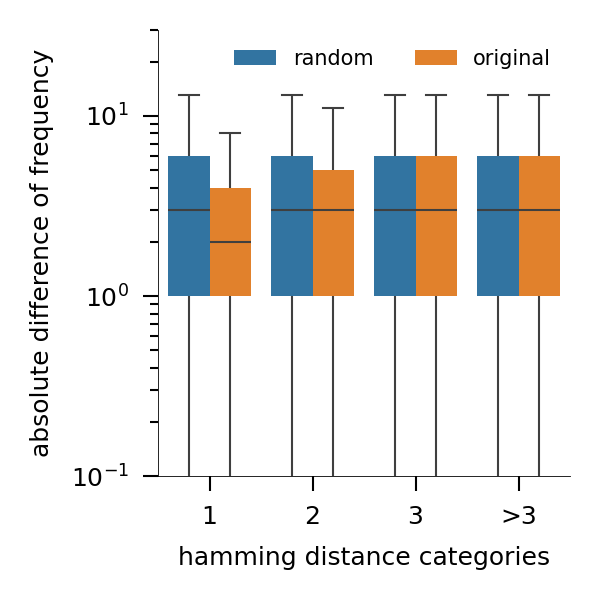

In [16]:
import seaborn as sns
fig, ax = plt.subplots(1, 1, figsize = (2.1,2.1), dpi = 300, sharex=True)
ax = sns.boxplot(df_filtered, x = "category", y = "freq_absolute_difference", hue = "type", ax=ax, linewidth = 0.5, boxprops=dict(linewidth=0),  showfliers=False)
ax.set_yscale('log')
ax = custom_figure_axis(ax, fontsize=6, show_ticks = True, rotation=0)
ax.legend(ncol = 2, fontsize=5, frameon=False)
ax.set_xlabel("hamming distance categories")
ax.set_ylim(0.1, 30)
ax.set_ylabel("absolute difference of frequency")
plt.tight_layout()
plt.savefig("random_fcgr_latest.pdf", dpi = 300)



In [17]:
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests
import utility

categories = [1, 2, 3, ">3"]
adjust_method = "fdr_bh"  # Benjamini-Hochberg FDR across categories

rows = []

for cat in categories:
    tmp = df_filtered[df_filtered["category"] == cat]
    y = tmp[tmp["type"] == "random"]["freq_absolute_difference"].dropna().to_numpy()
    x = tmp[tmp["type"] == "original"]["freq_absolute_difference"].dropna().to_numpy()

    if len(x) == 0 or len(y) == 0:
        rows.append({
            "category": cat,
            "n_original": len(x),
            "n_random": len(y),
            "p_value_raw": np.nan,
            "effect_size_name": "median_based_distance",
            "effect_size": np.nan,
            "ci_lower_95": np.nan,
            "ci_upper_95": np.nan,
        })
        continue

    p_value = utility.man_whiteney(x, y, alternative="less")
    effect_size, ci_lower, ci_upper = utility.median_based_distance_ci(
        x, y, n_boot=2000, ci=95, random_state=SEED
    )

    rows.append({
        "category": cat,
        "n_original": len(x),
        "n_random": len(y),
        "p_value_raw": float(p_value),
        "effect_size_name": "median_based_distance",
        "effect_size": effect_size,
        "ci_lower_95": ci_lower,
        "ci_upper_95": ci_upper,
    })

results_df = pd.DataFrame(rows)

# Apply multiplicity correction only on valid p-values, then map back
results_df["p_value_adjusted"] = np.nan
valid_mask = results_df["p_value_raw"].notna()
if valid_mask.any():
    results_df.loc[valid_mask, "p_value_adjusted"] = multipletests(
        results_df.loc[valid_mask, "p_value_raw"].to_numpy(),
        method=adjust_method,
    )[1]

results_df["p_adjust_method"] = adjust_method

# Stable, explicit category order in output
results_df["category"] = pd.Categorical(results_df["category"], categories=categories, ordered=True)
results_df = results_df.sort_values("category").reset_index(drop=True)

results_df = results_df[[
    "category",
    "n_random",
    "n_original",
    "p_value_raw",
    "p_value_adjusted",
    "p_adjust_method",
    "effect_size_name",
    "effect_size",
    "ci_lower_95",
    "ci_upper_95",
]]

results_df



,category,n_random,n_original,p_value_raw,p_value_adjusted,p_adjust_method,effect_size_name,effect_size,ci_lower_95,ci_upper_95
0,1,100000,100000,0.000000e+00,0.000000e+00,fdr_bh,median_based_distance,-0.632456,-0.632456,-0.632456
1,2,100000,100000,0.000000e+00,0.000000e+00,fdr_bh,median_based_distance,0.000000,0.000000,0.000000
2,3,100000,100000,1.227283e-88,1.636377e-88,fdr_bh,median_based_distance,0.000000,0.000000,0.000000
3,>3,100000,100000,1.878873e-02,1.878873e-02,fdr_bh,median_based_distance,0.000000,0.000000,0.000000
